In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

import matplotlib.pyplot as plt

In [2]:
qc = QuantumCircuit(3, 3)
qc.h([0, 1, 2])
qc.measure([0, 1, 2], [0, 1, 2])

In [3]:
ideal_sim = AerSimulator()
ideal_job = ideal_sim.run(transpile(qc, ideal_sim), shots=1024)
ideal_counts = ideal_job.result().get_counts()

In [4]:
fake_backend = FakeManilaV2()
noisy_sim = AerSimulator.from_backend(fake_backend)
noisy_job = noisy_sim.run(transpile(qc, noisy_sim), shots=1024)
noisy_counts = noisy_job.result().get_counts()

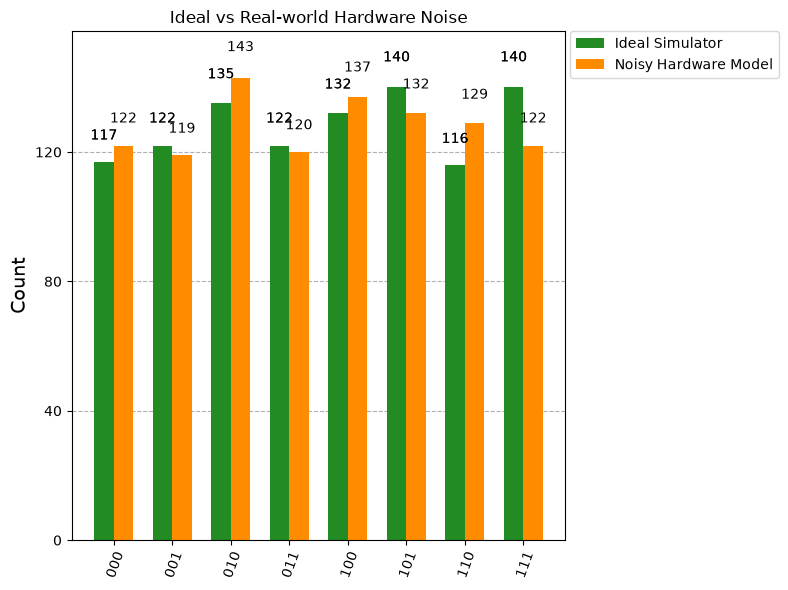

In [5]:
plot_histogram(
    [ideal_counts, noisy_counts],
    legend=["Ideal Simulator", "Noisy Hardware Model"],
    color=["forestgreen", "darkorange"],
    title="Ideal vs Real-world Hardware Noise",
    figsize=(8, 6)
)

